Painting dimensions: 822 x 650
Wall dimensions: 637 x 642

Painting corners:
[[  0.   0.]
 [821.   0.]
 [821. 649.]
 [  0. 649.]]

Frame opening corners:
[[330.  90.]
 [566.  90.]
 [566. 414.]
 [330. 414.]]

Perspective transformation matrix:
[[2.87454324e-01 0.00000000e+00 3.30000000e+02]
 [0.00000000e+00 4.99229584e-01 9.00000000e+01]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Output dimensions: 637 x 642
Saved: task10_painting_in_frame.jpg


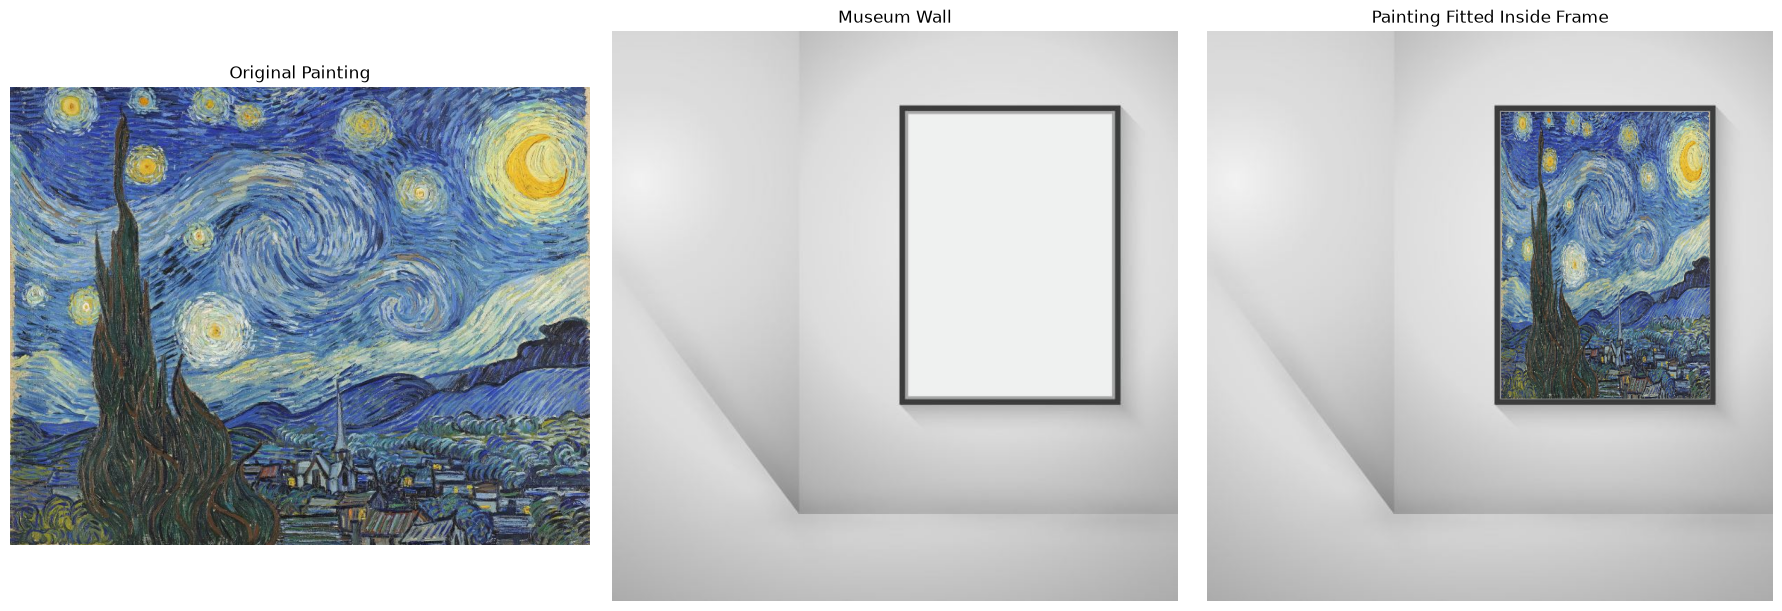

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Input and output files
# ---------------------------------------------------------
painting_path = "painting.jpg"
wall_path = "museum_wall.jpg"
output_path = "task10_painting_in_frame.jpg"

# ---------------------------------------------------------
# Read images
# ---------------------------------------------------------
painting = cv2.imread(painting_path)
wall = cv2.imread(wall_path)

if painting is None:
    raise FileNotFoundError(f"Could not read: {painting_path}")

if wall is None:
    raise FileNotFoundError(f"Could not read: {wall_path}")

hp, wp = painting.shape[:2]
hw, ww = wall.shape[:2]

print("Painting dimensions:", wp, "x", hp)
print("Wall dimensions:", ww, "x", hw)

# ---------------------------------------------------------
# PAINTING SOURCE CORNERS
#
# Order:
# 1. Top-Left
# 2. Top-Right
# 3. Bottom-Right
# 4. Bottom-Left
# ---------------------------------------------------------
src = np.array([
    [0, 0],
    [wp - 1, 0],
    [wp - 1, hp - 1],
    [0, hp - 1]
], dtype=np.float32)

print("\nPainting corners:")
print(src)

# ---------------------------------------------------------
# FRAME INNER CORNERS
#
# These coordinates are based on the uploaded wall image.
#
# The painting is placed INSIDE the dark frame,
# so the frame itself remains visible.
#
# Order:
# 1. Top-Left
# 2. Top-Right
# 3. Bottom-Right
# 4. Bottom-Left
# ---------------------------------------------------------
frame = np.array([
    [330, 90],     # Top-Left
    [566, 90],     # Top-Right
    [566, 414],    # Bottom-Right
    [330, 414]     # Bottom-Left
], dtype=np.float32)

print("\nFrame opening corners:")
print(frame)

# ---------------------------------------------------------
# Calculate perspective transformation
#
# This directly maps the entire painting into
# the frame opening.
# ---------------------------------------------------------
H = cv2.getPerspectiveTransform(src, frame)

print("\nPerspective transformation matrix:")
print(H)

# ---------------------------------------------------------
# Warp painting onto the wall canvas
# ---------------------------------------------------------
warped = cv2.warpPerspective(
    painting,
    H,
    (ww, hw)
)

# ---------------------------------------------------------
# Create mask for the warped painting
# ---------------------------------------------------------
painting_mask = np.ones(
    (hp, wp),
    dtype=np.uint8
) * 255

mask = cv2.warpPerspective(
    painting_mask,
    H,
    (ww, hw)
)

# ---------------------------------------------------------
# Make mask slightly smaller
#
# This prevents the painting from covering the frame
# border and gives a small margin inside the frame.
# ---------------------------------------------------------
kernel = np.ones((3, 3), np.uint8)

mask = cv2.erode(
    mask,
    kernel,
    iterations=1
)

# ---------------------------------------------------------
# Composite painting onto wall
# ---------------------------------------------------------
result = wall.copy()

mask_bool = mask > 0

result[mask_bool] = warped[mask_bool]

# ---------------------------------------------------------
# Save final result
# ---------------------------------------------------------
cv2.imwrite(output_path, result)

print("\nOutput dimensions:", ww, "x", hw)
print("Saved:", output_path)

# ---------------------------------------------------------
# Convert BGR to RGB for Matplotlib
# ---------------------------------------------------------
painting_rgb = cv2.cvtColor(
    painting,
    cv2.COLOR_BGR2RGB
)

wall_rgb = cv2.cvtColor(
    wall,
    cv2.COLOR_BGR2RGB
)

result_rgb = cv2.cvtColor(
    result,
    cv2.COLOR_BGR2RGB
)

# ---------------------------------------------------------
# Display results in Jupyter Notebook
# ---------------------------------------------------------
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(painting_rgb)
plt.title("Original Painting")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(wall_rgb)
plt.title("Museum Wall")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title("Painting Fitted Inside Frame")
plt.axis("off")

plt.tight_layout()
plt.show()
